In [ ]:
!pip install pandas==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.


In [ ]:
import pandas as pd
print(pd.__version__)

3.0.2


In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler


df = pd.read_pickle("submission_data.pkl")

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Data Types:\n", df.dtypes.value_counts())
print("\nMissing Values:", df.isnull().sum().sum())

Dataset Shape: (1618, 107)

Column Data Types:
 float64           100
int64               6
datetime64[us]      1
Name: count, dtype: int64

Missing Values: 0


In [ ]:
df['target'] = (df['Submission_Delay'] > 0).astype(int)

/tmp/ipykernel_3220/3390674232.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = (df['Submission_Delay'] > 0).astype(int)


In [ ]:
df = df.drop(columns=['Submission_Delay'])

In [ ]:
features = df.drop(columns=['target'])
feature_cols = features.columns

numeric_features = features.select_dtypes(include=[np.number])
numeric_cols = numeric_features.columns

In [ ]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(numeric_features), columns=numeric_cols)

In [ ]:
df_scaled['target'] = df['target'].values

In [ ]:
print("Scaled dataset shape:", df_scaled.shape)

Scaled dataset shape: (1618, 106)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

correlations = df_scaled.corr()['target']

In [ ]:
top_features = correlations.abs().sort_values(ascending=False).head(16).index
top_15_features = top_features.drop('target')

In [ ]:
print("Top 15 Features by Absolute Correlation:\n", correlations[top_15_features])

Top 15 Features by Absolute Correlation:
 x_04               -0.065493
x_05                0.060733
x_54                0.057554
Total_Words        -0.055027
Total_Characters   -0.053349
x_74               -0.047948
x_84               -0.046002
x_19               -0.044380
x_52               -0.043613
x_25                0.039566
x_100               0.039395
x_38                0.036348
Sno                 0.035988
x_02                0.035862
x_86                0.035243
Name: target, dtype: float64


<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

In [ ]:
top_15_corr_matrix = df_scaled[top_15_features].corr()

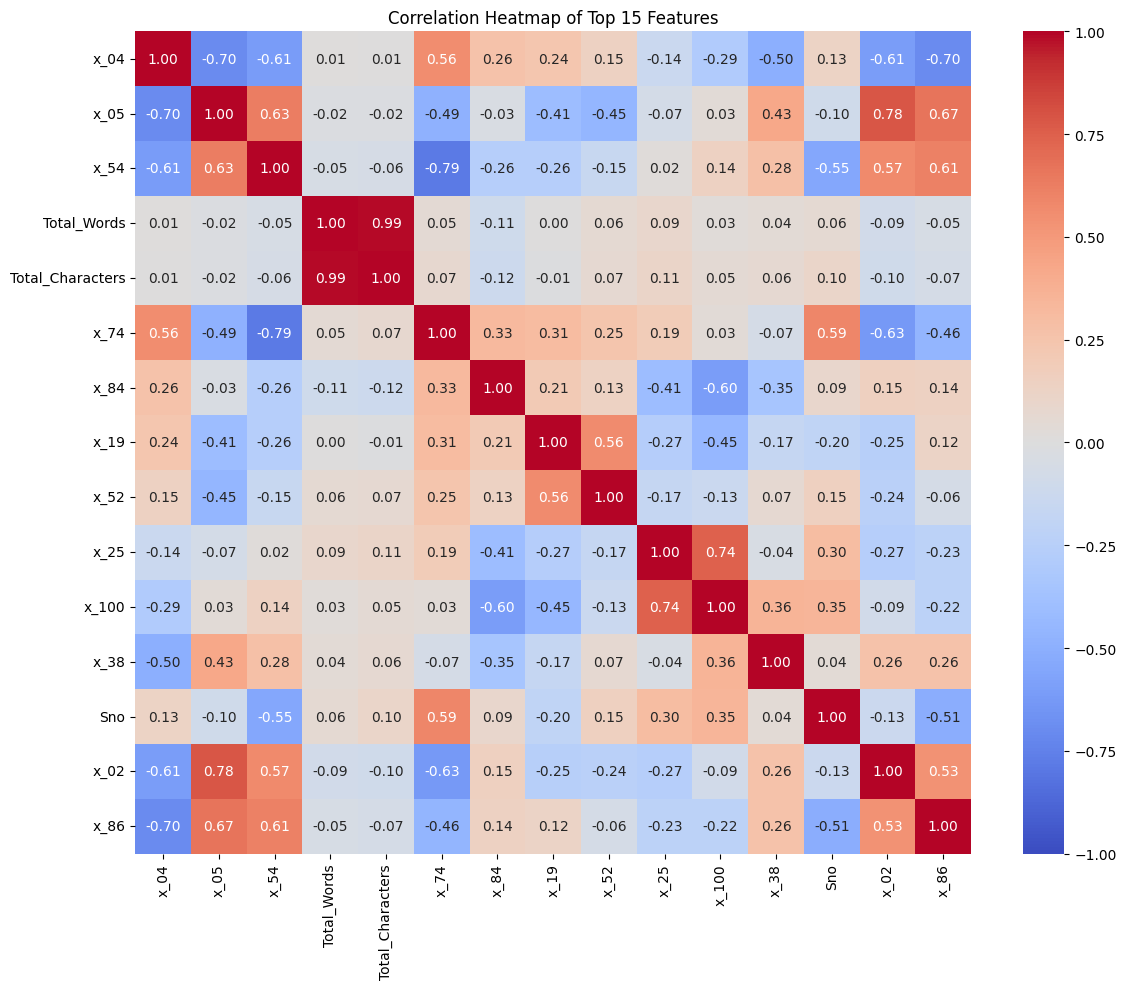

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(top_15_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Correlation Heatmap of Top 15 Features")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import umap

In [ ]:
X_all = df_scaled.drop(columns=['target'])
X_top15 = df_scaled[top_15_features]
y = df_scaled['target']

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_all)

In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap_all = reducer.fit_transform(X_all)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
X_umap_top15 = reducer.fit_transform(X_top15)

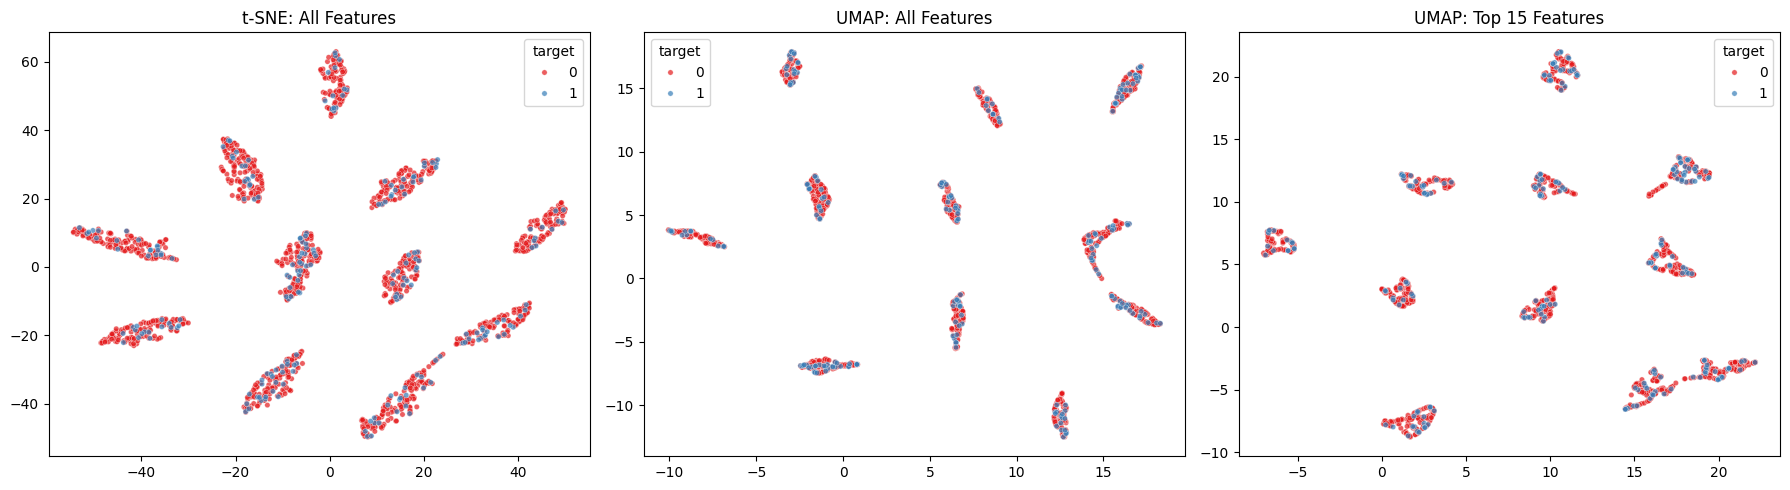

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='Set1', ax=axes[0], s=15, alpha=0.7)
axes[0].set_title('t-SNE: All Features')
sns.scatterplot(x=X_umap_all[:, 0], y=X_umap_all[:, 1], hue=y, palette='Set1', ax=axes[1], s=15, alpha=0.7)
axes[1].set_title('UMAP: All Features')

sns.scatterplot(x=X_umap_top15[:, 0], y=X_umap_top15[:, 1], hue=y, palette='Set1', ax=axes[2], s=15, alpha=0.7)
axes[2].set_title('UMAP: Top 15 Features')

plt.tight_layout()
plt.show()

In [ ]:


X_top15 = df_scaled[top_15_features]
y = df_scaled['target']

X_all = df_scaled.drop(columns=['target'])

X_train, X_test, y_train, y_test = train_test_split(X_top15, y, test_size=0.20, random_state=42)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y, test_size=0.20, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Support Vector Machine (SVC)": SVC(probability=True, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": f"{acc:.4f}",
        "Precision (Class 1)": f"{prec:.4f}",
        "Recall (Class 1)": f"{rec:.4f}",
        "F1-Score (Class 1)": f"{f1:.4f}",
        "AUC_ROC": f"{auc:.4f}"
    })

results_df = pd.DataFrame(results)
print("### Evaluation Metrics Table (Top 15 Features)\n")
print(results_df.to_markdown(index=False))

print("\n\n### Quick Test: Random Forest with ALL Features")
rf_all = RandomForestClassifier(random_state=42)
rf_all.fit(X_train_all, y_train_all)
y_pred_all = rf_all.predict(X_test_all)
print(f"Accuracy (All Features): {accuracy_score(y_test_all, y_pred_all):.4f}")
print(f"F1-Score (All Features): {f1_score(y_test_all, y_pred_all):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Evaluation Metrics Table (Top 15 Features)

| Model                        |   Accuracy |   Precision (Class 1) |   Recall (Class 1) |   F1-Score (Class 1) |   AUC_ROC |
|:-----------------------------|-----------:|----------------------:|-------------------:|---------------------:|----------:|
| Logistic Regression          |     0.8765 |                0      |              0     |               0      |    0.7063 |
| Support Vector Machine (SVC) |     0.8765 |                0      |              0     |               0      |    0.8951 |
| Random Forest Classifier     |     0.9259 |                0.9444 |              0.425 |               0.5862 |    0.9616 |


### Quick Test: Random Forest with ALL Features
Accuracy (All Features): 0.8704
F1-Score (All Features): 0.1600
